In [1]:
import os
import math
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.pyplot import gca
import matplotlib.colors as mcolors
import seaborn as sns

In [2]:
def load_benchmark_directory(directory):
    df = None
    # Iterate through files in the directory
    for filename in os.listdir(directory):
        filepath = os.path.join(directory, filename)
        
        curr_df = pd.read_csv(filepath)
        if df is None:
            df = curr_df
        else:
            df = pd.concat([df, curr_df])

    # sort df by gpu_count then slurm_job_id
    df = df.sort_values(by=['gpu_count', 'slurm_job_id']).reset_index(drop=True)
    return df

In [3]:
system = "frontier"

# xccl_df = load_benchmark_directory("data/all_reduce/perlmutter/xccl")
xccl_df = load_benchmark_directory("data/all_reduce/frontier/benchmark-2025-09-15/rccl")
xccl_df['time'] = xccl_df['time_xccl']
xccl_df['backend'] = 'xccl'
# pccl_df = load_benchmark_directory("data/all_reduce/perlmutter/pccl")
pccl_df = load_benchmark_directory("data/all_reduce/frontier/benchmark-2025-09-15/pccl-rccl+mpi")
pccl_df['time'] = pccl_df['time_pccl_cpp_rec']
pccl_df['backend'] = 'pccl'

In [4]:
pd.reset_option('display.max_rows')

In [5]:
xccl_avg_time = xccl_df.groupby(['gpu_count', 'output_size'])['time'].mean().reset_index().rename(columns={'time': 'mean'})
pccl_avg_time = pccl_df.groupby(['gpu_count', 'output_size'])['time'].mean().reset_index().rename(columns={'time': 'mean'})

xccl_avg_time, pccl_avg_time

(     gpu_count  output_size        mean
 0            8            1    0.140087
 1            8            2    0.157571
 2            8            4    0.208914
 3            8            8    0.311301
 4            8           16    0.338767
 ..         ...          ...         ...
 100       2048          256   26.475956
 101       2048          512   25.549443
 102       2048         1024   41.870461
 103       2048         2048   77.501575
 104       2048         4096  150.156177
 
 [105 rows x 3 columns],
      gpu_count  output_size        mean
 0            8            1    0.255110
 1            8            2    0.242358
 2            8            4    0.245154
 3            8            8    0.247038
 4            8           16    0.360951
 ..         ...          ...         ...
 98        2048          256   12.856855
 99        2048          512   25.752004
 100       2048         1024   52.081785
 101       2048         2048  105.455566
 102       2048         4096  

In [6]:
# Create line plots with log scale similar to the provided example
# Define colors and markers for different backends (using same colors as original example)
def get_colors():
    return ['#1f77b4', '#ff7f0e', '#2ca02c']  # Blue, Orange, Green

def get_markers():
    return ['o', 's', '^']

def get_linestyles():
    return ['-', '--', '-.']

def plot_scaling_comparison(allowed_message_sizes, system_name, y_ticks=[10**0, 10**1, 10**2], y_labels=['$10^0$', '$10^1$', '$10^2$']):
    """
    Plot scaling comparison for different message sizes
    
    Args:
        allowed_message_sizes: List of message sizes to plot (e.g., [64, 128])
        system_name: Name of the system for the plot title
        yticks_range: Tuple of (start, end) for 10^i range, e.g., (0, 3) for 10^0 to 10^2
                     If None, matplotlib will auto-scale
        ylim_range: Tuple of (ymin, ymax) for y-axis limits. If None, uses yticks_range
    """
    colors = get_colors()
    markers = get_markers() 
    linestyles = get_linestyles()
    
    plt.figure(figsize=(10, 6))
    
    # Plot for each backend
    for i, (df, method, color, marker) in enumerate(zip([xccl_avg_time, pccl_avg_time], 
                                                       ['XCCL', 'PCCL'], 
                                                       colors, markers)):
        for j, msg_size in enumerate(allowed_message_sizes):
            # Filter data for this message size
            df_this = df[df["output_size"] == msg_size]
            # Filter by GPU count range (adjust as needed)
            df_this = df_this[df_this["gpu_count"] <= 1024]
            df_this = df_this[df_this["gpu_count"] >= 32]
            
            # Plot the line
            plt.plot(df_this["gpu_count"], 
                    df_this["mean"], 
                    marker=marker,
                    label=f"{method} ({msg_size} MB)", 
                    linestyle=linestyles[j], 
                    color=color,
                    linewidth=2,
                    markersize=6)
    
    # Set log scales
    plt.xscale('log', base=2)
    plt.yscale('log', base=10)
    
    # Set x-axis ticks
    plt.xticks([2**i for i in range(5, 11)], [str(2**i) for i in range(5, 11)], fontsize=12)
    plt.yticks(y_ticks, y_labels, fontsize=12)
    
    # Set limits and labels
    plt.xlim(32, 1024)
    plt.xlabel("Number of GPUs", fontsize=14)
    plt.ylabel("Execution time (ms)", fontsize=14)
    plt.title(f"Comparison of all-reduce performance ({system_name.title()})", fontsize=14)
    plt.legend(loc="best", fontsize=12)
    plt.grid(True, alpha=0.3)
    
    # Save the plot
    plt.tight_layout()
    filename = f"allreduce_scaling_{system_name}_{allowed_message_sizes[1]}_{allowed_message_sizes[0]}.pdf"
    plt.savefig(filename, bbox_inches='tight', dpi=300)
    plt.show()
    print(f"Plot saved as: {filename}")

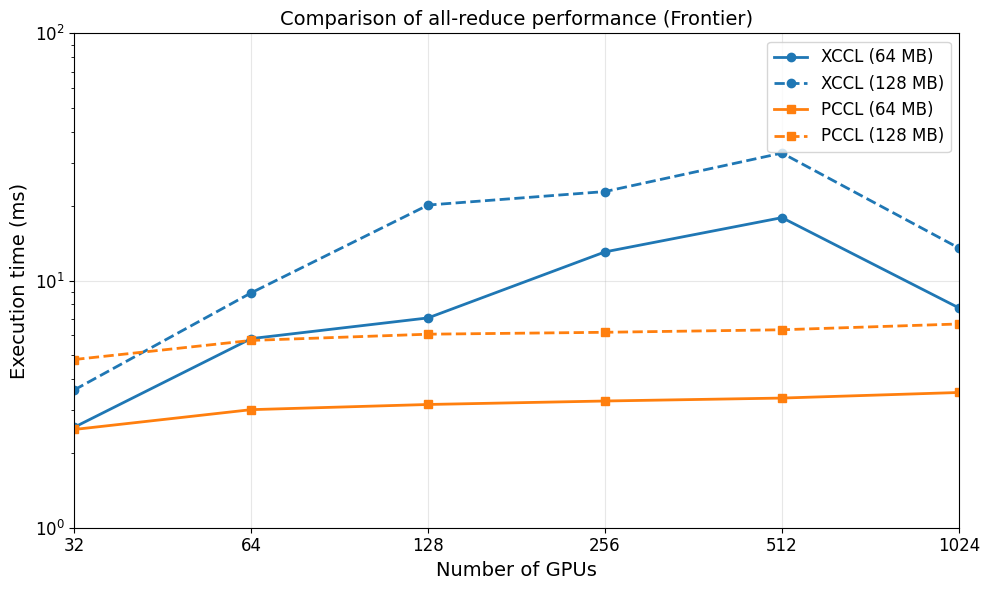

Plot saved as: allreduce_scaling_frontier_128_64.pdf


In [7]:
plot_scaling_comparison([64, 128], system)

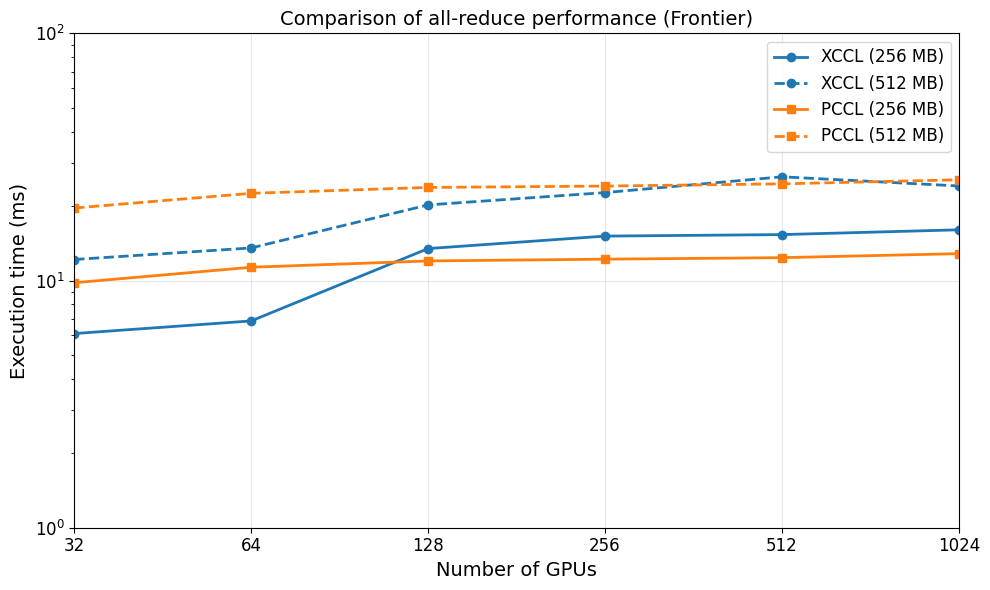

Plot saved as: allreduce_scaling_frontier_512_256.pdf


In [8]:
plot_scaling_comparison([256, 512], system)